In [462]:
import networkx as nx
import random 
import math

G = nx.Graph()

edges = [
    (1,2,1000),# ---- Compute common free slots inside region ----
    # NOTE: we DO NOT remove the old slots yet
   
    (1,3,1500),
    (1,8,2400),
    (2,3,600),
    (2,4,1200),
    (3,4,800),
    (4,5,700),
    (5,6,900),
    (6,7,800),
    (7,8,1000),
    (3,6,1600),
    (2,7,1700)
]

for u,v,w in edges:
    G.add_edge(u,v, weight=w)

nodes = list(G.nodes())

In [463]:


# ----------------------------
# Modulation table
# ----------------------------
modulation_formats = [
    {"name": "BPSK", "reach": 8000, "spectral_eff": 1},
    {"name": "QPSK", "reach": 4000, "spectral_eff": 2},
    {"name": "8QAM", "reach": 2000, "spectral_eff": 3},
    {"name": "16QAM", "reach": 1000, "spectral_eff": 4},
]

SLOT_WIDTH = 12.5  # GHz
GUARD_BAND = 1     # 1 slot

# ----------------------------
# Function to choose modulation
# ----------------------------
def choose_modulation(distance):
    # Choose highest spectral efficiency that satisfies reach
    for mod in reversed(modulation_formats):
        if distance <= mod["reach"]:
            return mod
    return modulation_formats[0]  # fallback to BPSK

# ---- Compute common free slots inside region ----
    # NOTE: we DO NOT remove the old slots yet
    # common = [0] * F
# ----------------------------
# Generate 1000 requests
# ----------------------------
requests = []

for i in range(1000):
    src, dst = random.sample(nodes, 2)
    bandwidth = random.choice([50, 100, 200])  # Gbps

    # Shortest path distance
    path = nx.shortest_path(G, src, dst, weight='weight')
    distance = nx.shortest_path_length(G, src, dst, weight='weight')

    # Choose modulation
    mod = choose_modulation(distance)

    # Slot capacity per slot
    slot_capacity = mod["spectral_eff"] * SLOT_WIDTH

    # Required slots
    slots = math.ceil(bandwidth / slot_capacity) + GUARD_BAND

    requests.append({
        "id": i,
        "source": src,
        "destination": dst,
        "bandwidth": bandwidth,
        "path": path,
        "distance": distance,
        "modulation": mod["name"],
        "slots_required": slots
    })


for r in requests[0:]:
    print(r)

{'id': 0, 'source': 3, 'destination': 8, 'bandwidth': 50, 'path': [3, 2, 7, 8], 'distance': 3300, 'modulation': 'QPSK', 'slots_required': 3}
{'id': 1, 'source': 3, 'destination': 5, 'bandwidth': 200, 'path': [3, 4, 5], 'distance': 1500, 'modulation': '8QAM', 'slots_required': 7}
{'id': 2, 'source': 5, 'destination': 8, 'bandwidth': 50, 'path': [5, 6, 7, 8], 'distance': 2700, 'modulation': 'QPSK', 'slots_required': 3}
{'id': 3, 'source': 7, 'destination': 6, 'bandwidth': 50, 'path': [7, 6], 'distance': 800, 'modulation': '16QAM', 'slots_required': 2}
{'id': 4, 'source': 1, 'destination': 5, 'bandwidth': 50, 'path': [1, 2, 4, 5], 'distance': 2900, 'modulation': 'QPSK', 'slots_required': 3}
{'id': 5, 'source': 5, 'destination': 8, 'bandwidth': 50, 'path': [5, 6, 7, 8], 'distance': 2700, 'modulation': 'QPSK', 'slots_required': 3}
{'id': 6, 'source': 3, 'destination': 7, 'bandwidth': 50, 'path': [3, 2, 7], 'distance': 2300, 'modulation': 'QPSK', 'slots_required': 3}
{'id': 7, 'source': 7, '

In [464]:
# Initialize spectrum map for all links
F = 720  # your size
all_links = [frozenset(edge) for edge in G.edges()]
spectrum_map = {link: [-1] * F for link in all_links}

In [465]:
# blocked = 0
# allocated = 0
# blocked_requests = []
# requests_dict = {}

# for req in requests:

#     path = req["path"]
#     k = req["slots_required"]

#     # Convert path nodes → link list
#     path_links = [frozenset({path[i], path[i+1]}) for i in range(len(path)-1)]

#     # -----------------------------
#     # Step 1: Compute common free slots across path
#     # -----------------------------
#     common = [0] * F

#     for i in range(F):
#         for link in path_links:
#             if spectrum_map[link][i] != -1:
#                 common[i] = 1
#                 break

#     # -----------------------------
#     # Step 2: Find free blocks
#     # -----------------------------
#     blocks = []
#     i = 0

#     while i < F:
#         if common[i] == 0:
#             start = i
#             while i < F and common[i] == 0:
#                 i += 1
#             size = i - start
#             blocks.append((start, size))
#         else:
#             i += 1

#     # -----------------------------
#     # Step 3: Exact-Fit selection
#     # -----------------------------
#     exact_blocks = [b for b in blocks if b[1] == k]

#     if exact_blocks:
#         start = exact_blocks[0][0]
#     else:
#         candidates = [b for b in blocks if b[1] >= k]
#         if not candidates:
#             blocked += 1
#             blocked_requests.append(req)
#             continue

#         start = min(candidates, key=lambda x: x[1])[0]

#     end = start + k

#     # -----------------------------
#     # Step 4: Allocate spectrum
#     # -----------------------------
#     for link in path_links:
#         for s in range(start, end):
#             spectrum_map[link][s] = req["id"]

#     requests_dict[req["id"]] = {
#         "slots": (start, end - 1),
#         "path": path_links
#     }

#     allocated += 1

# print("Allocated:", allocated)
# print("Blocked:", blocked)
# print("Blocking Probability:", blocked / len(requests))

In [466]:
import random

blocked = 0
allocated = 0
blocked_requests = []
requests_dict = {}

for req in requests:
    path = req["path"]
    slots_needed = req["slots_required"]

    # Convert path nodes → link list
    path_links = [frozenset({path[i], path[i+1]}) for i in range(len(path)-1)]

    # All possible starting indices
    possible_starts = list(range(F - slots_needed + 1))
    random.shuffle(possible_starts)  # Random allocation

    allocated_flag = False

    for start in possible_starts:
        end = start + slots_needed

        # Check continuity + contiguity
        feasible = True
        for link in path_links:
            if any(spectrum_map[link][s] != -1 for s in range(start, end)):
                feasible = False
                break

        if feasible:
            # Allocate on ALL links
            for link in path_links:
                for s in range(start, end):
                    spectrum_map[link][s] = req["id"]

            requests_dict[req["id"]] = {
                "slots": (start, end - 1),
                "path": path_links
            }
         
        

            allocated += 1
            allocated_flag = True
            break

    if not allocated_flag:
        blocked += 1
        blocked_requests.append(req)

print("Allocated:", allocated)
print("Blocked:", blocked)
print("Blocking Probability:", blocked / len(requests))

Allocated: 801
Blocked: 199
Blocking Probability: 0.199


In [467]:
for link in spectrum_map:
    print(f"\nLink {set(link)}:")
    print(spectrum_map[link][:100])  # show first 100 slots


Link {1, 2}:
[-1, -1, 443, 443, 443, 443, 443, 443, 443, 443, 443, -1, 858, 858, 858, -1, -1, 787, 787, 787, 845, 845, 845, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 46, 46, 46, -1, -1, -1, 73, 73, 73, 73, 73, 73, 73, 73, 73, -1, 945, 945, 945, 945, 945, -1, -1, -1, 492, 492, 492, 984, 984, 984, 13, 13, 13, 177, 177, 177, 177, 177, 213, 213, 213, 213, 213, 559, 559, 559, 451, 451, 451, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 206, 206, 206, 206, 206]

Link {1, 3}:
[954, 954, 954, -1, -1, -1, -1, 828, 828, 828, 828, -1, -1, -1, 50, 50, 50, 50, 50, -1, -1, -1, -1, -1, -1, 601, 601, 601, -1, -1, 367, 367, 367, -1, -1, -1, -1, 956, 956, 956, -1, -1, -1, -1, -1, 576, 576, 576, 576, 576, -1, -1, -1, -1, -1, -1, -1, -1, 569, 569, 569, -1, -1, -1, 609, 609, 609, 609, 609, -1, 306, 306, 306, 306, 306, 306, 306, 306, 306, -1, 237, 237, 237, 237, -1, 934, 934, 934, -1, -1, -1, -1, 777, 777, 777, 777, 777, 777, 777, -1]

Link {8, 1}:
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -

In [468]:
import csv

filename = "exact_fit_allocn.csv"

with open(filename, mode="w", newline="") as file:
    writer = csv.writer(file)

    # Header
    writer.writerow(["source", "destination", "required_slots"])

    # Write only required fields
    for req in requests:
        writer.writerow([
            req["source"],
            req["destination"],
            req["slots_required"]
        ])

print("CSV file created:", filename)

CSV file created: exact_fit_allocn.csv


In [469]:
from collections import Counter

# Extract required_slots
slot_values = [req["slots_required"] for req in requests]

# Count frequency
slot_counts = Counter(slot_values)

# Print sorted results
print("Unique slot sizes:", sorted(slot_counts.keys()))
print("\nFrequency of each slot size:")
for slot_size in sorted(slot_counts):
    print(f"{slot_size} slots → {slot_counts[slot_size]} requests")

Unique slot sizes: [2, 3, 4, 5, 7, 9]

Frequency of each slot size:
2 slots → 71 requests
3 slots → 356 requests
4 slots → 95 requests
5 slots → 214 requests
7 slots → 119 requests
9 slots → 145 requests


In [470]:
from collections import Counter

slot_values = [req["slots_required"] for req in requests]
slot_counts = Counter(slot_values)

In [471]:
total_requests = sum(slot_counts.values())

slot_proportions = {
    k: slot_counts[k] / total_requests
    for k in sorted(slot_counts)
}

In [472]:
print(slot_proportions)

{2: 0.071, 3: 0.356, 4: 0.095, 5: 0.214, 7: 0.119, 9: 0.145}


In [473]:
region_sizes = {
    k: int(round(slot_proportions[k] * F))
    for k in slot_proportions
}

In [474]:
print(region_sizes)

{2: 51, 3: 256, 4: 68, 5: 154, 7: 86, 9: 104}


In [475]:
difference = F - sum(region_sizes.values())

# Add remaining slots to largest demand class
largest_class = max(region_sizes, key=region_sizes.get)
region_sizes[largest_class] += difference

In [476]:
sum(region_sizes.values()) == 720

True

In [477]:
region_boundaries = {}

current_start = 0

for k in sorted(region_sizes):
    size = region_sizes[k]
    start = current_start
    end = current_start + size - 1
    region_boundaries[k] = (start, end)
    current_start = end + 1

In [478]:
print(region_boundaries)

{2: (0, 50), 3: (51, 307), 4: (308, 375), 5: (376, 529), 7: (530, 615), 9: (616, 719)}


In [479]:
#this checks whether a lightpath is inside its assigned spectrum region
def is_inside_region(start, end, region_start, region_end):
    return start >= region_start and end <= region_end

In [480]:
def link_fragmentation(slots):

    F = len(slots)

    Sab = 0
    for i in range(F):
        if slots[i] != -1:
            Sab = i + 1

    L = []
    i = 0

    while i < Sab:

        if slots[i] == -1:
            start = i
            while i < Sab and slots[i] == -1:
                i += 1
            L.append(i - start)

        else:
            i += 1

    if len(L) == 0:
        return 0, Sab

    numerator = Sab * len(L)

    denominator = math.sqrt(sum(l*l for l in L) / len(L))

    return numerator / denominator, Sab

In [481]:
def network_fragmentation(spectrum_map, F):

    total_frag = 0
    smax = 0

    for link, slots in spectrum_map.items():

        frag, Sab = link_fragmentation(slots)

        total_frag += frag

        smax = max(smax, Sab)

    avg_link_frag = total_frag / len(spectrum_map)

    return avg_link_frag * (smax / F)

In [482]:
print("\nInitial Network Fragmentation:",
      network_fragmentation(spectrum_map, F))


Initial Network Fragmentation: 15650.512601541499


In [483]:
# this function attempts to move one lightpath from its original region to its desired region
#requests_dict mantain starting index and path information
def migrate_to_region(req_id, spectrum_map, requests_dict,                                   
                      region_boundaries, F):

    info = requests_dict[req_id]                  # get the information of that lightpath
    path_links = info["path"]                     #get the info about lightpaths used
    old_start, old_end = info["slots"]            #this gets the current occupied slots of the lightpath
    k = old_end - old_start + 1                   # compute the slot size , (slots + 1 guard band)
  
    region_start, region_end = region_boundaries[k]     # find the preferred region where to allocate it e.g. if k =5 region starts/ends 393/553

    # If already inside region → nothing to do
    if is_inside_region(old_start, old_end, 
                        region_start, region_end):
        return False

   
    common = [0] * F   # it creates a temporary spectrum view to see where the lightpath could be shifted

    for i in range(region_start, region_end + 1):   # this loop iterates over every slot range of the preferred region

        for link in path_links:          # we check on all the paths of that lightpath request

            # ignore the current request's own slots
            if spectrum_map[link][i] != -1 and spectrum_map[link][i] != req_id:  # checks the slot i on a link is occupoied by other lightpath request
                common[i] = 1        # updating to 1 means this slot cant be used
                break

    # ---- Find contiguous blocks ----
    blocks = []   # stores all freee contiguous blocks found in that region e.g. [(200,3), (208,8)]
    i = region_start
        # loop through the region
        # to detect as much as free contiguous slot as possible
    while i <= region_end:

        if common[i] == 0:  # if slot found is free, update the starting block
            start = i

            while i <= region_end and common[i] == 0:  # this checks how many slots are free based on the starting slot found in the loop above
                i += 1

            size = i - start   # it computes the block size found
            blocks.append((start, size))   # add the information to the list

        else:
            i += 1  # if the slot is blocked we simply move to the next block

    # ---- Exact-Fit rule ----
    #exact fit  means if a block exists with exactly k slots , then allocate the lightpath of slot k there 
    # if not exists then choose the smallest block which is just greater than k 


    exact_blocks = [b for b in blocks if b[1] == k]  #It scans all detected blocks and keeps those whose size equals k.

    if exact_blocks:   #If an Exact Block Exists
        new_start = exact_blocks[0][0]   # we take the first exact fit block

    else:

        candidates = [b for b in blocks if b[1] >= k]   #This selects all blocks whose size is greater than or equal to k.

        if not candidates:                    # it cant be alloted
            return False

        new_start = min(candidates, key=lambda x: x[1])[0]   # This selects the block with the smallest size among the candidates.

    new_end = new_start + k - 1    # compute the last slot of the new allocation 

    # ---- MAKE step (allocate new path first) ----
    for link in path_links:                   # loop through every link of the path, to ensure spectrum contiguity
        for s in range(new_start, new_end + 1):   # loops through the slot being used by the new lightpath
            spectrum_map[link][s] = req_id        # update the request id

    # ---- BREAK step (remove old path) ----
    for link in path_links:
        for s in range(old_start, old_end + 1):    # loop over through the old slots which were being used by the lightpath 
            if s < new_start or s > new_end:        # so that we do not accidentally delete slots that belong to the new allocation.     
                spectrum_map[link][s] = -1               # mark the slot as free

    # update dictionary
    requests_dict[req_id]["slots"] = (new_start, new_end)

    return True

In [484]:
# # function to call migrate_to_region() for each request and count how many migrations succeeded

# def soft_region_migration(spectrum_map, requests_dict, 
#                           region_boundaries, F):

#     moved = 0    #counts how many lightpaths were successfully migrated.

#     for req_id in requests_dict.keys():    # loop through all currently allocated lightpaths

#         #attempt migration if done update the counter
#         if migrate_to_region(req_id, spectrum_map, 
#                              requests_dict, 
#                              region_boundaries, F):
#             moved += 1

#     print("Moved into preferred region:", moved)

In [485]:
# def soft_region_migration(spectrum_map, requests_dict,
#                           region_boundaries, F):

#     moved = 0

#     # Sort requests by slot size (largest first)
#     sorted_requests = sorted(
#         requests_dict.items(),
#         key=lambda x: x[1]["slots"][1] - x[1]["slots"][0],
#         reverse=True
#     )

#     for req_id, info in sorted_requests:

#         if migrate_to_region(req_id,
#                              spectrum_map,
#                              requests_dict,
#                              region_boundaries,
#                              F):

#             moved += 1

#     print("Moved into preferred region:", moved)

In [486]:
import matplotlib.pyplot as plt

def iterative_soft_region_migration(spectrum_map,
                                    requests_dict,
                                    region_boundaries,
                                    F):

    iteration = 0

    frag_values = []
    moved_values = []

    while True:

        iteration += 1
        moved = 0

        print(f"\nIteration {iteration}")

        frag_before = network_fragmentation(spectrum_map, F)
        print("Fragmentation before:", frag_before)

        # store value
        frag_values.append(frag_before)

        sorted_requests = sorted(
            requests_dict.items(),
            key=lambda x: x[1]["slots"][1] - x[1]["slots"][0],
            reverse=True
        )

        for req_id, info in sorted_requests:

            if migrate_to_region(req_id,
                                 spectrum_map,
                                 requests_dict,
                                 region_boundaries,
                                 F):

                moved += 1

        frag_after = network_fragmentation(spectrum_map, F)

        print("Lightpaths moved:", moved)
        print("Fragmentation after:", frag_after)
        print("Defragmentation improvement:", frag_before - frag_after)

        moved_values.append(moved)

        if moved == 0:
            frag_values.append(frag_after)
            print("No further migration possible.")
            break

    return frag_values, moved_values

In [487]:
frag_values, moved_values = iterative_soft_region_migration(
    spectrum_map,
    requests_dict,
    region_boundaries,
    F
)


Iteration 1
Fragmentation before: 15650.512601541499
Lightpaths moved: 176
Fragmentation after: 11261.313377512146
Defragmentation improvement: 4389.199224029353

Iteration 2
Fragmentation before: 11261.313377512146
Lightpaths moved: 59
Fragmentation after: 9847.739228308583
Defragmentation improvement: 1413.5741492035631

Iteration 3
Fragmentation before: 9847.739228308583


Lightpaths moved: 27
Fragmentation after: 10058.643449651545
Defragmentation improvement: -210.90422134296205

Iteration 4
Fragmentation before: 10058.643449651545
Lightpaths moved: 8
Fragmentation after: 10229.646487563974
Defragmentation improvement: -171.00303791242914

Iteration 5
Fragmentation before: 10229.646487563974
Lightpaths moved: 4
Fragmentation after: 10287.338876955337
Defragmentation improvement: -57.69238939136267

Iteration 6
Fragmentation before: 10287.338876955337
Lightpaths moved: 6
Fragmentation after: 9913.091709516166
Defragmentation improvement: 374.2471674391709

Iteration 7
Fragmentation before: 9913.091709516166
Lightpaths moved: 0
Fragmentation after: 9913.091709516166
Defragmentation improvement: 0.0
No further migration possible.


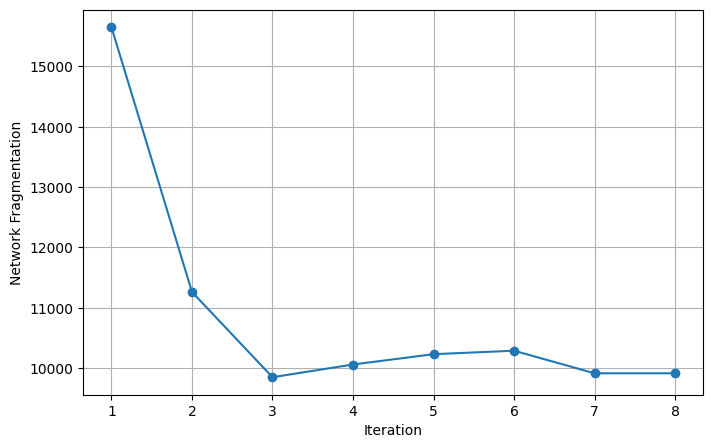

In [489]:
import matplotlib.pyplot as plt

iterations = list(range(1, len(frag_values)+1))

plt.figure(figsize=(8,5))
plt.plot(iterations, frag_values, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Network Fragmentation")
# plt.title("Defragmentation Progress")
plt.grid(True)
plt.show()